# Hybrid Model for Classification

Found 10000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.
Train Data Size: 10000
Validation Data Size: 1000
Processed batch 1/313 (32 samples)
Processed batch 2/313 (32 samples)
Processed batch 3/313 (32 samples)
Processed batch 4/313 (32 samples)
Processed batch 5/313 (32 samples)
Processed batch 6/313 (32 samples)
Processed batch 7/313 (32 samples)
Processed batch 8/313 (32 samples)
Processed batch 9/313 (32 samples)
Processed batch 10/313 (32 samples)
Processed batch 11/313 (32 samples)
Processed batch 12/313 (32 samples)
Processed batch 13/313 (32 samples)
Processed batch 14/313 (32 samples)
Processed batch 15/313 (32 samples)
Processed batch 16/313 (32 samples)
Processed batch 17/313 (32 samples)
Processed batch 18/313 (32 samples)
Processed batch 19/313 (32 samples)
Processed batch 20/313 (32 samples)
Processed batch 21/313 (32 samples)
Processed batch 22/313 (32 samples)
Processed batch 23/313 (32 samples)
Processed batch 24/313 (32 samples)
Processe

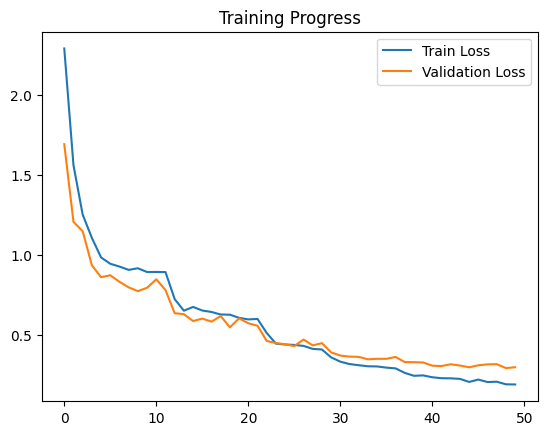

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9960 - loss: 0.1185

✅ Proposed Train Accuracy: 99.56%
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9325 - loss: 0.3022
Test Accuracy: 93.80%
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step 


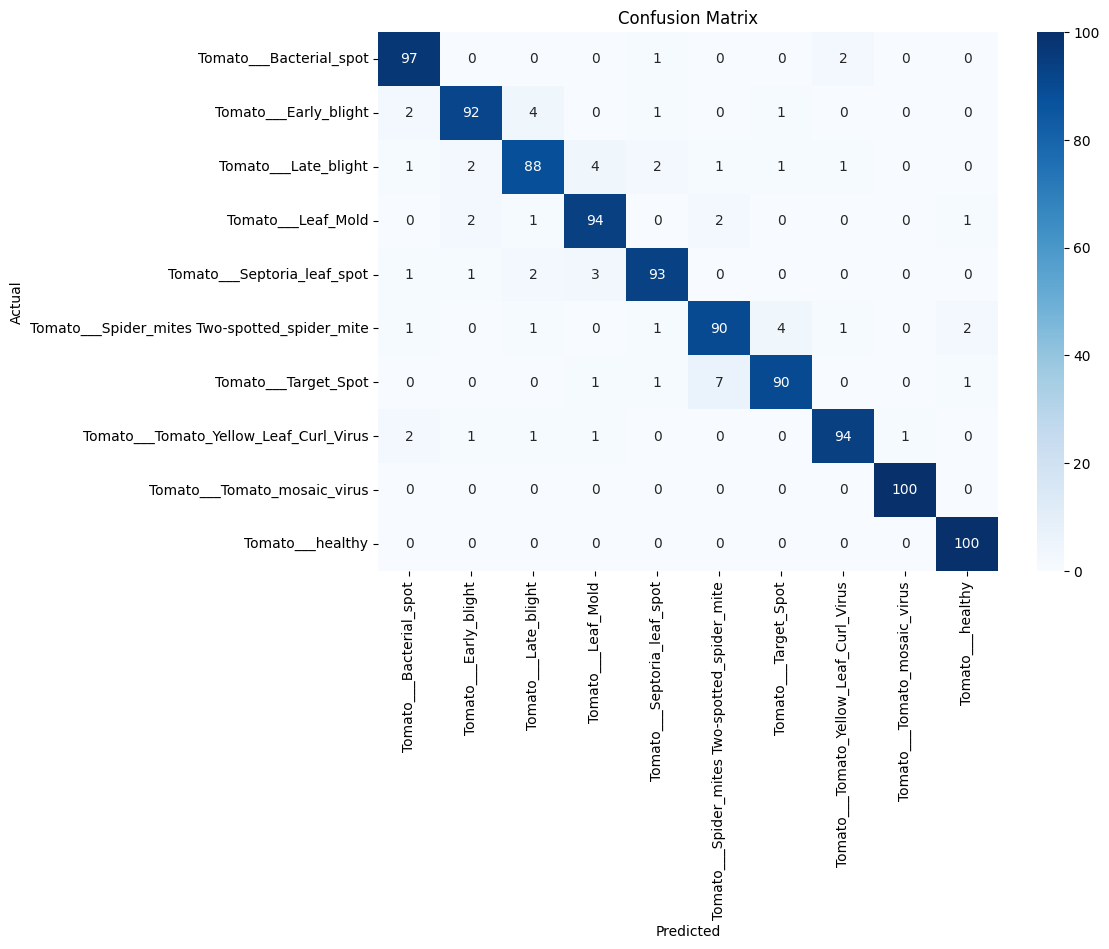

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.93      0.97      0.95       100
                        Tomato___Early_blight       0.94      0.92      0.93       100
                         Tomato___Late_blight       0.91      0.88      0.89       100
                           Tomato___Leaf_Mold       0.91      0.94      0.93       100
                  Tomato___Septoria_leaf_spot       0.94      0.93      0.93       100
Tomato___Spider_mites Two-spotted_spider_mite       0.90      0.90      0.90       100
                         Tomato___Target_Spot       0.94      0.90      0.92       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.96      0.94      0.95       100
                 Tomato___Tomato_mosaic_virus       0.99      1.00      1.00       100
                             Tomato___healthy       0.96      1.00      0.98       100

                                     accu

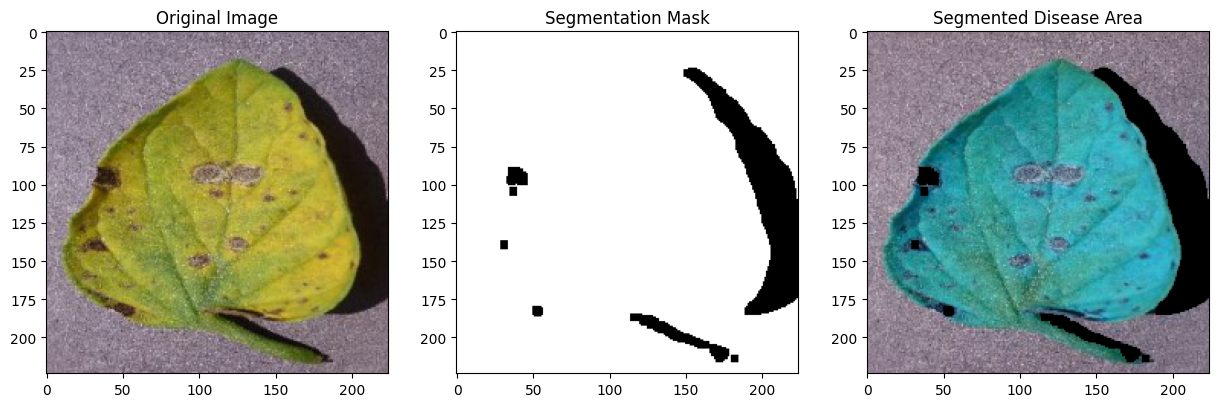

Predicted Class: Tomato___Septoria_leaf_spot
Confidence Score: 97.26%
Severity Score: 100.41%


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import cv2
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import sys  # 

# ========================
# STEP 1: DATA AUGMENTATION & PREPROCESSING
# ========================
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = datagen.flow_from_directory(
    "train",  
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",  
    shuffle=True  # 
)

val_data = datagen.flow_from_directory(
    "val",  
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False  
)

print("Train Data Size:", train_data.samples)
print("Validation Data Size:", val_data.samples)

def segment_leaf(image):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel = lab[:, :, 0]
    _, adaptive_mask = cv2.threshold(l_channel, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = np.ones((5,5), np.uint8)
    clean_mask = cv2.morphologyEx(adaptive_mask, cv2.MORPH_CLOSE, kernel)
    return clean_mask, cv2.bitwise_and(image, image, mask=clean_mask)

# ========================
# STEP 2: CNN FEATURE EXTRACTION (EfficientNetB0)
# ========================
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# UNFREEZE LAST FEW LAYERS FOR FINE-TUNING
for layer in base_model.layers[-60:]:  
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)  
cnn_feature_extractor = Model(inputs=base_model.input, outputs=x)

# ========================
# STEP 3: HANDCRAFTED FEATURE EXTRACTION FUNCTION
# ========================
def extract_handcrafted_features(img):
    img = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [256], [0, 256]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [256], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [256], [0, 256]).flatten()
    return np.concatenate([hist_h, hist_s, hist_v])  # Shape: (768,)

# ========================
# STEP 4: FEATURE EXTRACTION FUNCTION 
# ========================
def extract_features(data_gen):
    all_features = []
    all_labels = []
    
    steps = len(data_gen)
    
    for i, (batch_imgs, batch_labels) in enumerate(data_gen):
        batch_features = cnn_feature_extractor.predict(batch_imgs, verbose=0)

        batch_imgs_uint8 = (batch_imgs * 255.0).astype(np.uint8)

        handcrafted_features = []
        for img in batch_imgs_uint8:
            mask, segmented = segment_leaf(img)  # Apply improved segmentation
            leaf_features = extract_handcrafted_features(segmented)  # Extract from segmented leaf
            handcrafted_features.append(leaf_features)

        handcrafted_features = np.array(handcrafted_features)

        # Append combined features
        all_features.append(np.hstack([batch_features, handcrafted_features]))  
        all_labels.extend(batch_labels)

        print(f"Processed batch {i+1}/{steps} ({len(batch_labels)} samples)")
        
        if i + 1 >= steps:
            break

    return np.vstack(all_features), np.array(all_labels, dtype=np.int32)


# ========================
# STEP 5: PREPARE FEATURE DATASET 
# ========================
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

# Standardize features properly
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

print("Train Features Shape:", train_features.shape)  
print("Validation Features Shape:", val_features.shape)  
print("First 10 Train Labels (raw output):", train_labels[:10].tolist())
print("Class Indices:", train_data.class_indices)  
print("Unique Train Labels:", np.unique(train_labels))  

# ========================
# STEP 6: CLASSIFICATION MODEL
# ========================
from tensorflow.keras.regularizers import l2
input_layer = Input(shape=(train_features.shape[1],))  
x = Dense(2048, activation="relu", kernel_regularizer=l2(0.0005))(input_layer)  
x = BatchNormalization()(x)
x = Dropout(0.4)(x)  # Increased dropout to avoid overfitting
x = Dense(1024, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(len(train_data.class_indices), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=x)

model = Model(inputs=input_layer, outputs=x)
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ========================
# STEP 7: TRAIN THE MODEL 
# ========================
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7)

history = model.fit(
    train_features, train_labels,
    validation_data=(val_features, val_labels),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training Progress")
plt.show()


# ========================
# STEP 8: EVALUATE MODEL
# ========================
loss, acc = model.evaluate(train_features, train_labels)
print(f"\n✅ Proposed Train Accuracy: {acc * 100:.2f}%")

test_loss, test_acc = model.evaluate(val_features, val_labels)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

y_pred = model.predict(val_features)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices

plot_confusion_matrix(val_labels, y_pred_classes, list(train_data.class_indices.keys()))
print(classification_report(val_labels, y_pred_classes, target_names=list(train_data.class_indices.keys())))

# Function to estimate disease spots based on image processing
def estimate_disease_area(image, class_name):
    """Calculate total disease-affected area on the leaf."""
    mask, segmented = segment_leaf(image)
    gray = cv2.cvtColor(segmented, cv2.COLOR_BGR2GRAY)
    _, disease_mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    # Find contours and compute total disease area
    contours, _ = cv2.findContours(disease_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    disease_area = sum(cv2.contourArea(c) for c in contours)

    return disease_area if class_name != "Healthy" else 0

# Function to compute severity score based on image processing
def compute_severity(image, predicted_class):
    """Calculate the Percentage of Disease Severity (PDS)"""
    leaf_mask, segmented = segment_leaf(image)

    if predicted_class == "Tomato___healthy":
        return 0.0

    # Compute leaf area & disease area
    leaf_area = cv2.countNonZero(leaf_mask)
    disease_area = estimate_disease_area(image, predicted_class)

    # Compute severity score
    severity_score = (disease_area / leaf_area) * 100 if leaf_area > 0 else 0
    return round(severity_score, 2)

# Dictionary to store severity scores for each class
severity_per_class = {class_name: [] for class_name in train_data.class_indices.keys()}

# Process validation data
for i, (batch_imgs, batch_labels) in enumerate(val_data):
    batch_imgs_uint8 = (batch_imgs * 255.0).astype(np.uint8)
    
    for j, img in enumerate(batch_imgs_uint8):
        predicted_class = list(train_data.class_indices.keys())[int(batch_labels[j])]
        severity_score = compute_severity(img, predicted_class)
        severity_per_class[predicted_class].append(severity_score)
  
    print(f"Processed batch {i+1}/{len(val_data)}")
    
    if i + 1 >= len(val_data):  
        break  # Stop after all validation samples are processed

# Convert severity scores to DataFrame for easy viewing
df = pd.DataFrame({class_name: [np.mean(scores)] for class_name, scores in severity_per_class.items()}).T
df.columns = ["Average Severity Score"]
print(df)

def test_single_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Extract Features
    img_array = img_rgb.astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    cnn_features = cnn_feature_extractor.predict(img_array, verbose=0)
    mask, segmented_img = segment_leaf(img)
    handcrafted_features = extract_handcrafted_features(segmented_img)
    
    combined_features = np.hstack([cnn_features.flatten(), handcrafted_features])
    combined_features = scaler.transform([combined_features])  # Standardize features

    # Predict Class
    preds = model.predict(combined_features)  # Probabilities for each class
    predicted_class_idx = np.argmax(preds)
    predicted_class = list(train_data.class_indices.keys())[predicted_class_idx]
    confidence = preds[0][predicted_class_idx] * 100  # Confidence score

    # Compute Severity
    severity = compute_severity(img, predicted_class)

    # Display Results
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img_rgb)
    ax[0].set_title("Original Image")
    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Segmentation Mask")
    ax[2].imshow(segmented_img)
    ax[2].set_title("Segmented Disease Area")

    plt.show()

    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence Score: {confidence:.2f}%")  # Show confidence
    print(f"Severity Score: {severity}%")

# Test with an Image
test_single_image("val/Tomato___Septoria_leaf_spot/0b6a9374-858d-49ce-8a94-ab57c957718c___Matt.S_CG 2488.jpg")  # Replace with actual path


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


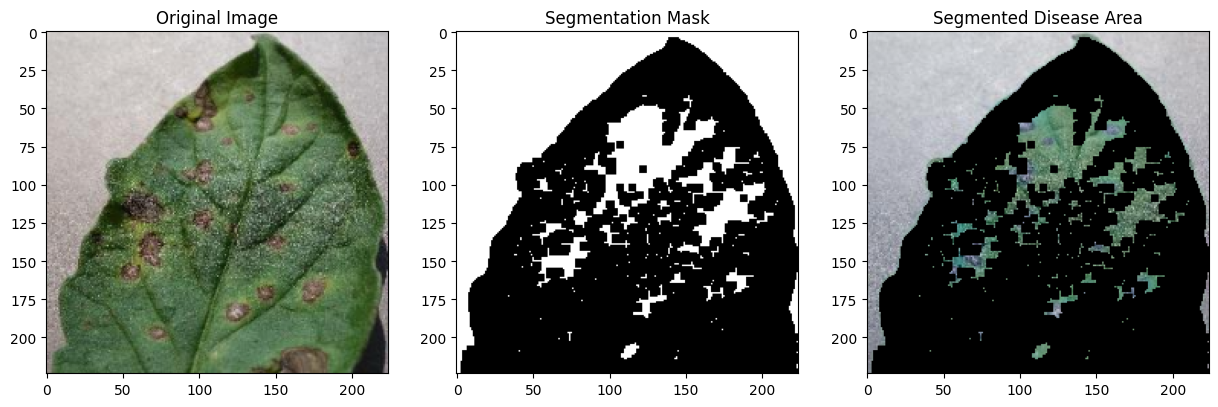

Predicted Class: Tomato___Early_blight
Confidence Score: 99.49%
Severity Score: 92.14%


In [13]:
# Test with an Image
test_single_image("val/Tomato___Early_blight/0d5f65a3-b32f-4565-b63a-c6da73c1322b___RS_Erly.B 8310.jpg")  # Replace with actual path

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


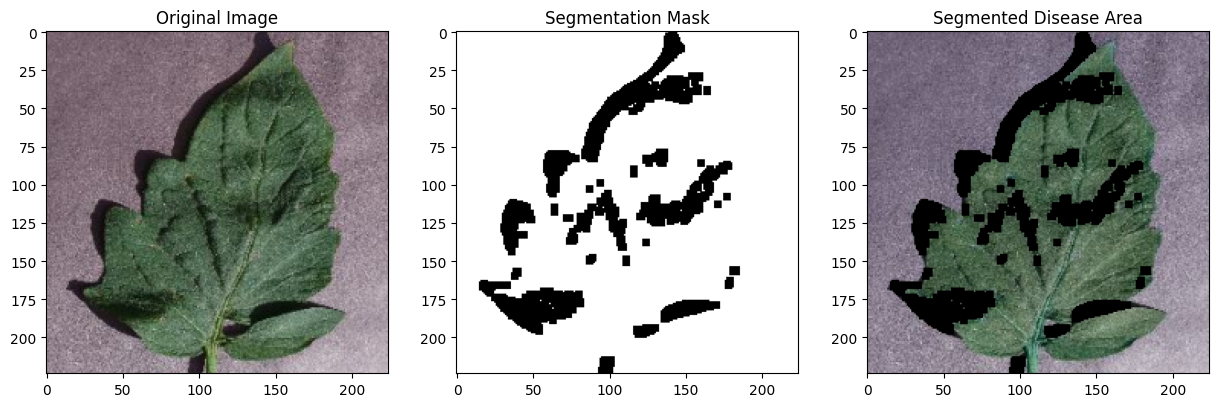

Predicted Class: Tomato___Target_Spot
Confidence Score: 97.12%
Severity Score: 108.68%


In [23]:
# Test with an Image
test_single_image("val/Tomato___Target_Spot/0abb0bf0-8a1e-4699-80ee-c434385d9514___Com.G_TgS_FL 8115.jpg")  # Replace with actual path

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


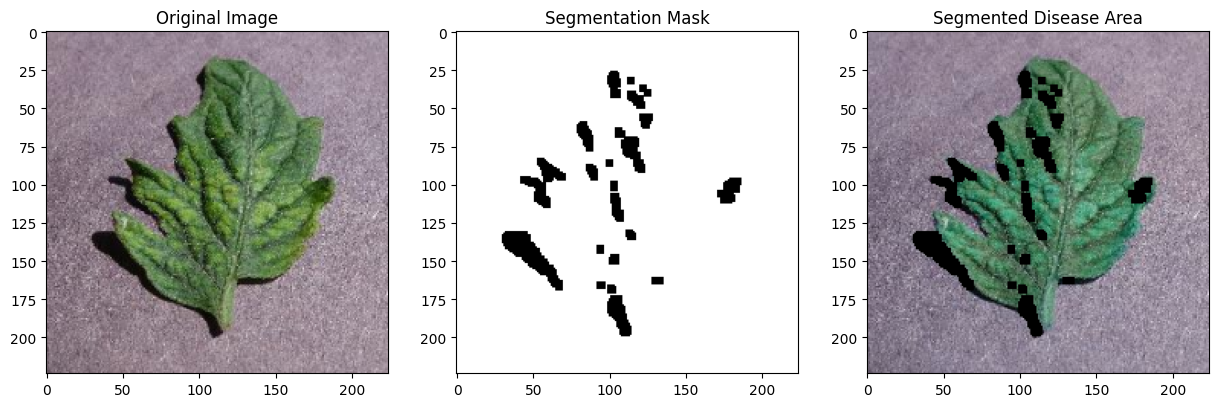

Predicted Class: Tomato___Tomato_mosaic_virus
Confidence Score: 100.00%
Severity Score: 104.73%


In [28]:
# Test with an Image
test_single_image("val/Tomato___Tomato_mosaic_virus/0befa341-0db3-49f4-b4fc-beeb05854bff___PSU_CG 2338.jpg")  # Replace with actual path

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


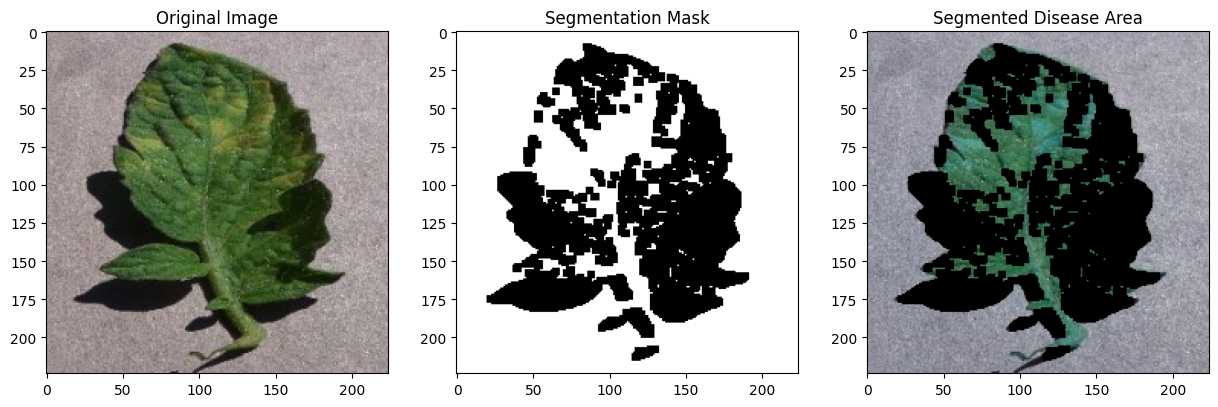

Predicted Class: Tomato___Leaf_Mold
Confidence Score: 99.91%
Severity Score: 145.86%


In [32]:
# Test with an Image
test_single_image("val/Tomato___Leaf_Mold/0d54c850-da9a-498d-a636-ddeac067fd7e___Crnl_L.Mold 6746.jpg")  # Replace with actual path

# Existing MobileNetV2 

C:\Users\91948\anaconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 193s 596ms/step - accuracy: 0.3317 - loss: 2.2418 - val_accuracy: 0.7140 - val_loss: 0.8615 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 185s 591ms/step - accuracy: 0.6478 - loss: 1.0313 - val_accuracy: 0.7490 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 634ms/step - accuracy: 0.7174 - loss: 0.8371 - val_accuracy: 0.8130 - val_loss: 0.5567 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 234s 748ms/step - accuracy: 0.7547 - loss: 0.7146 - val_accuracy: 0.8090 - val_loss: 0.5668 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 275s 880ms/step - accuracy: 0.7719 - loss: 0.6632 - val_accuracy: 0.8210 - val_loss: 0.5254 - learning_rate: 1.0000e-04
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 276s 881ms/step - accuracy: 0.7891 - loss: 0.6263 - val_accuracy: 0.8230 - val_loss: 0.5090 - learning_rate: 1.0000e-04
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 

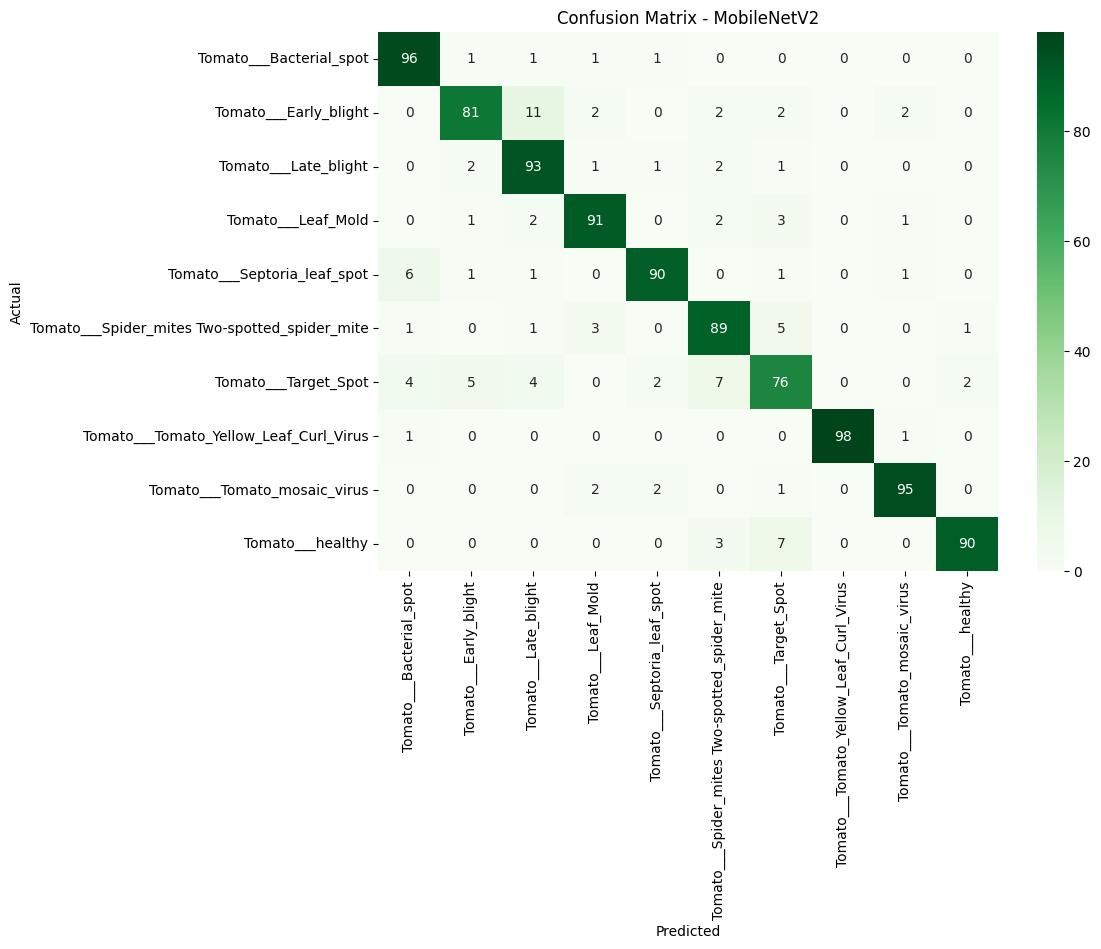

In [3]:
from tensorflow.keras.applications import MobileNetV2

# ===========================
# STEP 1: Load MobileNetV2 Base
# ===========================
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base layers
for layer in mobilenet_base.layers:
    layer.trainable = False

# Custom classification head
x = mobilenet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=mobilenet_base.input, outputs=predictions)

# ===========================
# STEP 2: Compile & Train
# ===========================
mobilenet_model.compile(optimizer=Adam(learning_rate=1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)

history_mobilenet = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

# ===========================
# STEP 3: Evaluation
# ===========================
loss, acc = mobilenet_model.evaluate(train_data)
print(f"✅ Train Accuracy: {acc * 100:.2f}%")

val_loss, val_acc = mobilenet_model.evaluate(val_data)
print(f"\n✅ MobileNetV2 Validation Accuracy: {val_acc * 100:.2f}%")

# ===========================
# STEP 4: Classification Metrics
# ===========================
y_true = val_data.classes
y_pred_probs = mobilenet_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\nClassification Report (MobileNetV2):")
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=train_data.class_indices.keys(), yticklabels=train_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()


# Existing EfficientNet

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 340s 1s/step - accuracy: 0.1007 - loss: 2.4975 - val_accuracy: 0.1000 - val_loss: 2.3236 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 303s 968ms/step - accuracy: 0.1038 - loss: 2.4032 - val_accuracy: 0.1000 - val_loss: 2.4380 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 295s 942ms/step - accuracy: 0.1035 - loss: 2.3836 - val_accuracy: 0.1000 - val_loss: 2.3924 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 294s 938ms/step - accuracy: 0.1054 - loss: 2.3594 - val_accuracy: 0.1000 - val_loss: 2.3948 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 297s 950ms/step - accuracy: 0.1139 - loss: 2.3415 - val_accuracy: 0.1000 - val_loss: 2.4078 - learning_rate: 5.0000e-05
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 307s 981ms/step - accuracy: 0.1103 - loss: 2.3312 - val_accuracy: 0.1000 - val_loss: 2.4203 - learning_rate: 5.0000e-05
313/313 ━━━━━━━━━━━━━━━━━━━━ 271s 864ms/ste

C:\Users\91948\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91948\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\91948\anaconda3\envs\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


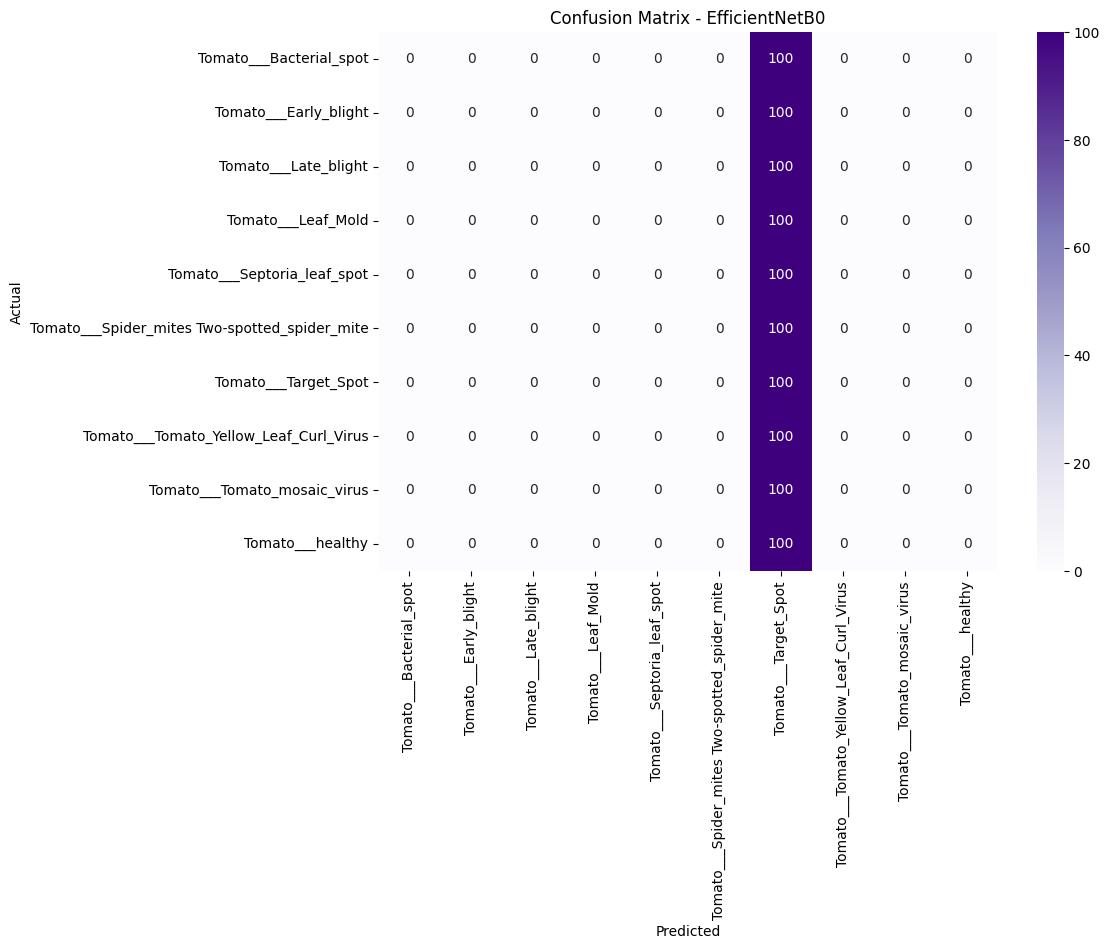

In [4]:
# ===========================
# STEP 1: Load EfficientNetB0 Base
# ===========================
efficientnet_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers initially
for layer in efficientnet_base.layers:
    layer.trainable = False

# Add custom classification head
x = GlobalAveragePooling2D()(efficientnet_base.output)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

efficientnet_model = Model(inputs=efficientnet_base.input, outputs=output)

# ===========================
# STEP 2: Compile and Train
# ===========================
efficientnet_model.compile(optimizer=Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5)

history_efficientnet = efficientnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

# ===========================
# STEP 3: Evaluate
# ===========================
loss, acc = efficientnet_model.evaluate(train_data)
print(f"✅ EfficientNetB0 Train Accuracy: {acc * 100:.2f}%")

val_loss, val_acc = efficientnet_model.evaluate(val_data)
print(f"\n✅ EfficientNetB0 Validation Accuracy: {val_acc * 100:.2f}%")

# ===========================
# STEP 4: Metrics
# ===========================
y_true = val_data.classes
y_pred_probs = efficientnet_model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report (EfficientNetB0):")
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=train_data.class_indices.keys(), yticklabels=train_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")
plt.show()


# Existing CNN + Handcrafted Features (No Segmentation)

Processed batch 1/313
Processed batch 2/313
Processed batch 3/313
Processed batch 4/313
Processed batch 5/313
Processed batch 6/313
Processed batch 7/313
Processed batch 8/313
Processed batch 9/313
Processed batch 10/313
Processed batch 11/313
Processed batch 12/313
Processed batch 13/313
Processed batch 14/313
Processed batch 15/313
Processed batch 16/313
Processed batch 17/313
Processed batch 18/313
Processed batch 19/313
Processed batch 20/313
Processed batch 21/313
Processed batch 22/313
Processed batch 23/313
Processed batch 24/313
Processed batch 25/313
Processed batch 26/313
Processed batch 27/313
Processed batch 28/313
Processed batch 29/313
Processed batch 30/313
Processed batch 31/313
Processed batch 32/313
Processed batch 33/313
Processed batch 34/313
Processed batch 35/313
Processed batch 36/313
Processed batch 37/313
Processed batch 38/313
Processed batch 39/313
Processed batch 40/313
Processed batch 41/313
Processed batch 42/313
Processed batch 43/313
Processed batch 44/3

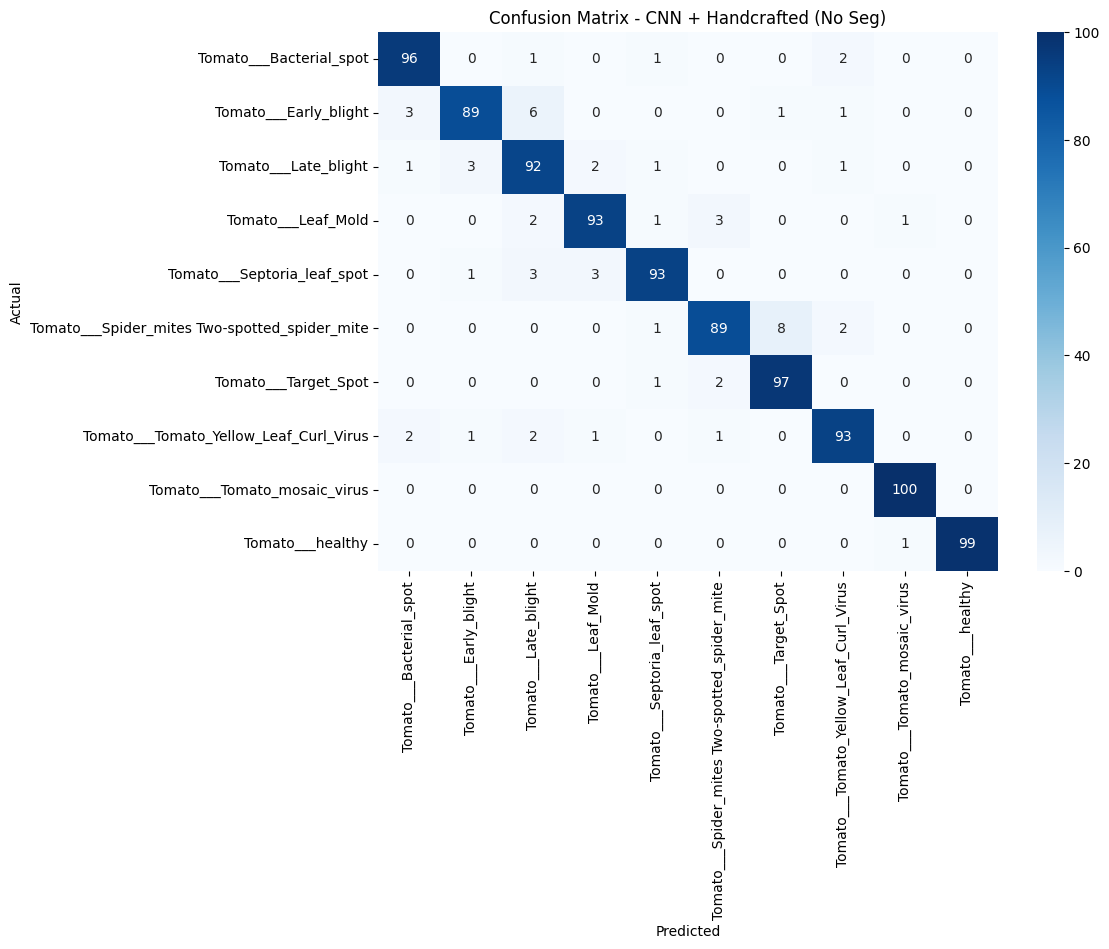

In [5]:
# ========================
# 1. HANDCRAFTED FEATURE FUNCTION
# ========================
def extract_handcrafted_features(img):
    img = cv2.resize(img, (224, 224))
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [256], [0, 256]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [256], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [256], [0, 256]).flatten()
    return np.concatenate([hist_h, hist_s, hist_v])  # Shape: (768,)

# ========================
# 2. CNN FEATURE EXTRACTOR (EfficientNetB0)
# ========================
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
cnn_feature_extractor = Model(inputs=base_model.input, outputs=x)

# ========================
# 3. EXTRACT FEATURES (CNN + Handcrafted, No Segmentation)
# ========================
def extract_features(data_gen):
    all_features = []
    all_labels = []

    for i, (batch_imgs, batch_labels) in enumerate(data_gen):
        cnn_features = cnn_feature_extractor.predict(batch_imgs, verbose=0)
        handcrafted_features = []

        batch_imgs_uint8 = (batch_imgs * 255).astype(np.uint8)
        for img in batch_imgs_uint8:
            leaf_features = extract_handcrafted_features(img)  # No segmentation
            handcrafted_features.append(leaf_features)

        handcrafted_features = np.array(handcrafted_features)
        combined_features = np.hstack([cnn_features, handcrafted_features])
        all_features.append(combined_features)
        all_labels.extend(batch_labels)

        print(f"Processed batch {i+1}/{len(data_gen)}")

        if i + 1 >= len(data_gen):
            break

    return np.vstack(all_features), np.array(all_labels, dtype=np.int32)

# ========================
# 4. PREPARE FEATURE DATASETS
# ========================
train_features, train_labels = extract_features(train_data)
val_features, val_labels = extract_features(val_data)

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# ========================
# 5. CLASSIFIER MODEL (MLP)
# ========================
input_layer = Input(shape=(train_features.shape[1],))
x = Dense(1024, activation="relu")(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(len(train_data.class_indices), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=x)
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ========================
# 6. TRAINING
# ========================
history = model.fit(
    train_features, train_labels,
    validation_data=(val_features, val_labels),
    epochs=30,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
    ]
)

# ========================
# 7. EVALUATION
# ========================
loss, acc = model.evaluate(train_features, train_labels)
print(f"\n✅ CNN + Handcrafted (No Segmentation) Train Accuracy: {acc * 100:.2f}%")

loss, acc = model.evaluate(val_features, val_labels)
print(f"\n✅ CNN + Handcrafted (No Segmentation) Accuracy: {acc * 100:.2f}%")

y_pred_probs = model.predict(val_features)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(val_labels, y_pred, target_names=list(train_data.class_indices.keys())))

cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_data.class_indices, yticklabels=train_data.class_indices)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN + Handcrafted (No Seg)")
plt.show()


# Existing CNN + Segmentation (No Handcrafted)

Processed batch 1/313
Processed batch 2/313
Processed batch 3/313
Processed batch 4/313
Processed batch 5/313
Processed batch 6/313
Processed batch 7/313
Processed batch 8/313
Processed batch 9/313
Processed batch 10/313
Processed batch 11/313
Processed batch 12/313
Processed batch 13/313
Processed batch 14/313
Processed batch 15/313
Processed batch 16/313
Processed batch 17/313
Processed batch 18/313
Processed batch 19/313
Processed batch 20/313
Processed batch 21/313
Processed batch 22/313
Processed batch 23/313
Processed batch 24/313
Processed batch 25/313
Processed batch 26/313
Processed batch 27/313
Processed batch 28/313
Processed batch 29/313
Processed batch 30/313
Processed batch 31/313
Processed batch 32/313
Processed batch 33/313
Processed batch 34/313
Processed batch 35/313
Processed batch 36/313
Processed batch 37/313
Processed batch 38/313
Processed batch 39/313
Processed batch 40/313
Processed batch 41/313
Processed batch 42/313
Processed batch 43/313
Processed batch 44/3

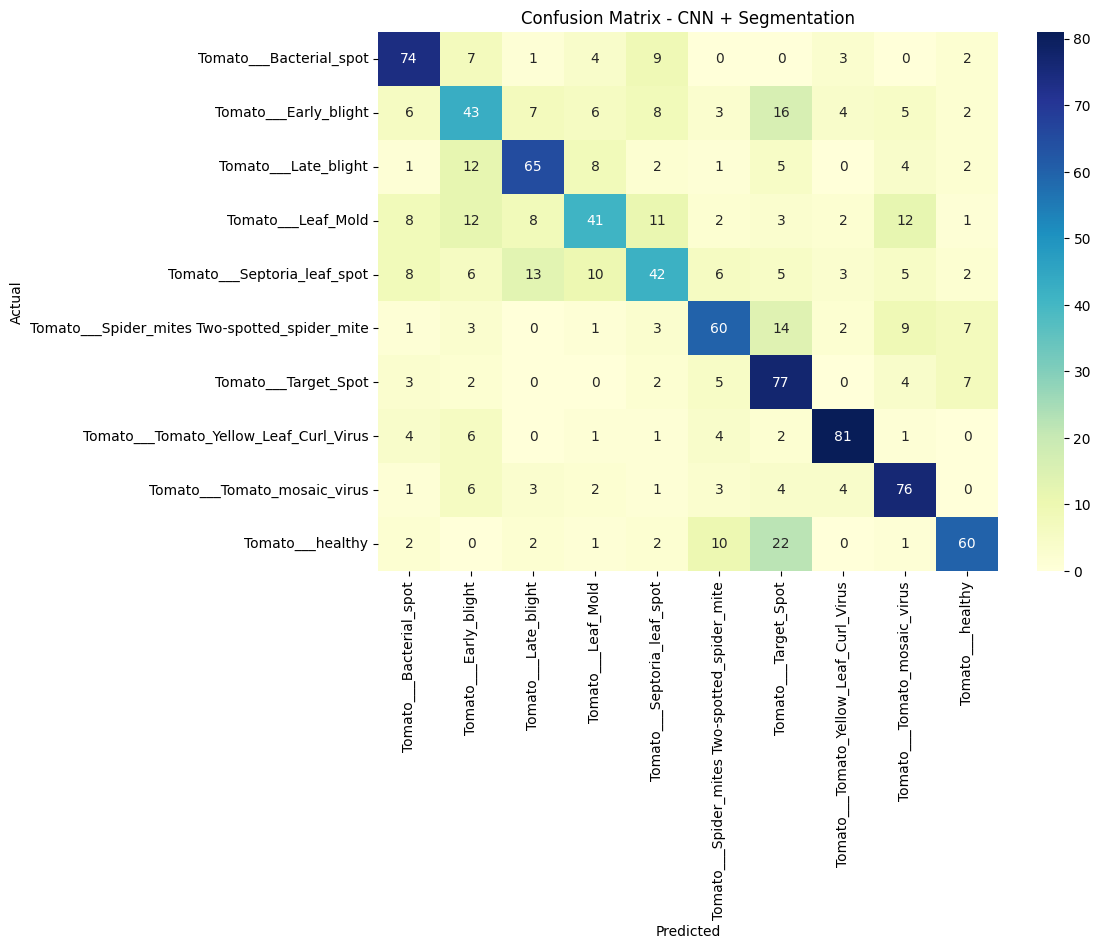

In [7]:
# ========================
# 1. Leaf Segmentation (HSV Mask)
# ========================
def segment_leaf(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([25, 40, 40])
    upper_green = np.array([90, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
    segmented = cv2.bitwise_and(image, image, mask=mask)
    return segmented

# ========================
# 2. CNN Feature Extractor (EfficientNetB0)
# ========================
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
cnn_feature_extractor = Model(inputs=base_model.input, outputs=x)

# ========================
# 3. Extract CNN Features from Segmented Image
# ========================
def extract_cnn_features(data_gen):
    all_features = []
    all_labels = []

    for i, (batch_imgs, batch_labels) in enumerate(data_gen):
        batch_imgs_uint8 = (batch_imgs * 255).astype(np.uint8)

        segmented_imgs = []
        for img in batch_imgs_uint8:
            seg = segment_leaf(img)
            seg = cv2.resize(seg, (224, 224))
            seg = seg.astype(np.float32) / 255.0
            segmented_imgs.append(seg)

        segmented_imgs = np.array(segmented_imgs)
        features = cnn_feature_extractor.predict(segmented_imgs, verbose=0)
        all_features.append(features)
        all_labels.extend(batch_labels)

        print(f"Processed batch {i+1}/{len(data_gen)}")

        if i + 1 >= len(data_gen):
            break

    return np.vstack(all_features), np.array(all_labels, dtype=np.int32)

# ========================
# 4. Prepare Feature Data
# ========================
train_features, train_labels = extract_cnn_features(train_data)
val_features, val_labels = extract_cnn_features(val_data)

scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
val_features = scaler.transform(val_features)

# ========================
# 5. Classification Model (MLP)
# ========================
input_layer = Input(shape=(train_features.shape[1],))
x = Dense(1024, activation="relu")(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(len(train_data.class_indices), activation="softmax")(x)

model = Model(inputs=input_layer, outputs=x)
model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# ========================
# 6. Training
# ========================
history = model.fit(
    train_features, train_labels,
    validation_data=(val_features, val_labels),
    epochs=30,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
    ]
)

# ========================
# 7. Evaluation
# ========================
loss, acc = model.evaluate(train_features, train_labels)
print(f"\n✅ CNN + Segmentation Train Accuracy: {acc * 100:.2f}%")

loss, acc = model.evaluate(val_features, val_labels)
print(f"\n✅ CNN + Segmentation Accuracy: {acc * 100:.2f}%")

y_pred_probs = model.predict(val_features)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(val_labels, y_pred, target_names=list(train_data.class_indices.keys())))

cm = confusion_matrix(val_labels, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=train_data.class_indices, yticklabels=train_data.class_indices)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN + Segmentation")
plt.show()
